pour les valleur aleatoire
n=100: Lomuto=6.556510925292969e-05s | Partition2=7.390975952148438e-05s
n=1000: Lomuto=0.0016477108001708984s | Partition2=0.0012404918670654297s
n=10000: Lomuto=0.01767587661743164s | Partition2=0.017554283142089844s
n=100000: Lomuto=0.21886396408081055s | Partition2=0.21692252159118652s
n=1000000: Lomuto=3.096416473388672s | Partition2=3.1155107021331787s
pour les valleur croissante
n=50: Lomuto=0.00012302398681640625s | Partition2=8.535385131835938e-05s
n=100: Lomuto=0.0004725456237792969s | Partition2=0.0003249645233154297s
n=500: Lomuto=0.012508392333984375s | Partition2=0.008505821228027344s
n=1000: Lomuto=0.05017828941345215s | Partition2=0.034208059310913086s
n=2000: Lomuto=0.2287435531616211s | Partition2=0.14018988609313965s
pour les valleur decroissante
n=50: Lomuto=9.822845458984375e-05s | Partition2=8.20159912109375e-05s
n=100: Lomuto=0.0003714561462402344s | Partition2=0.000301361083984375s
n=500: Lomuto=0.008714437484741211s | Partition2=0.007

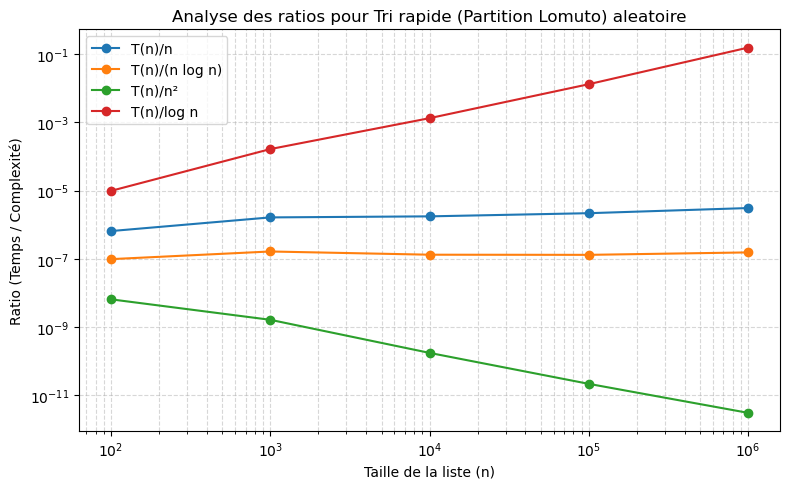

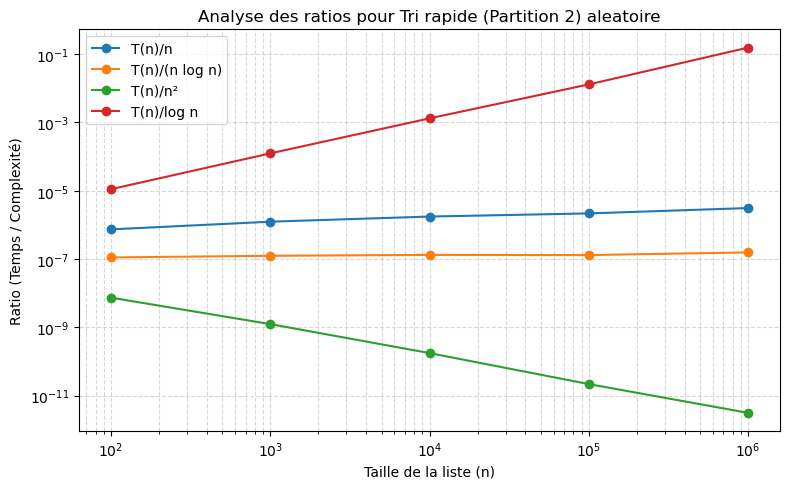

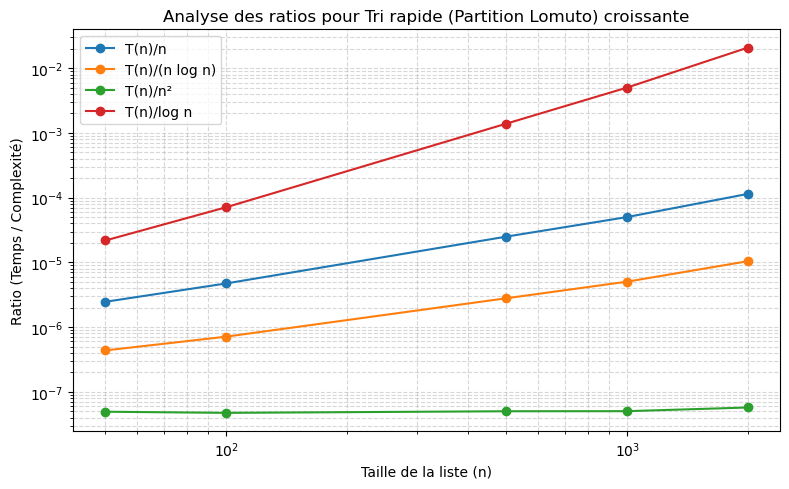

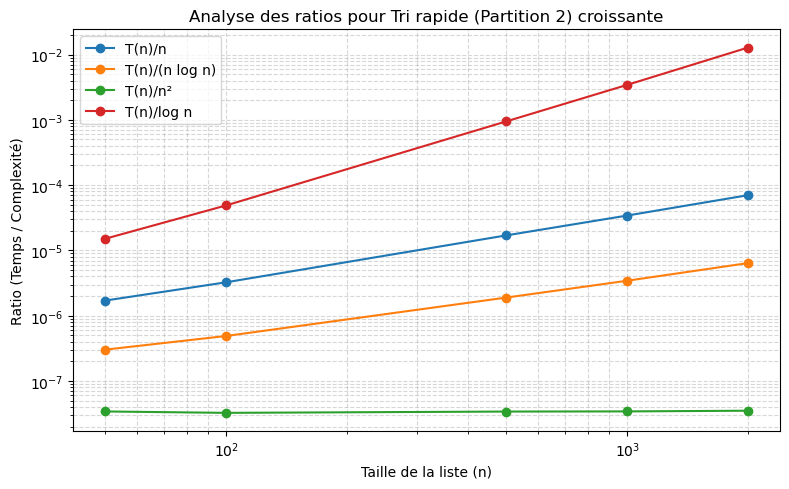

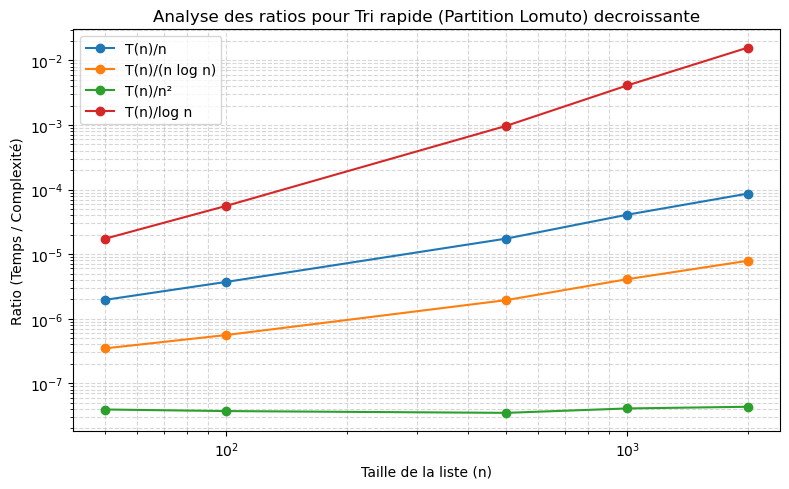

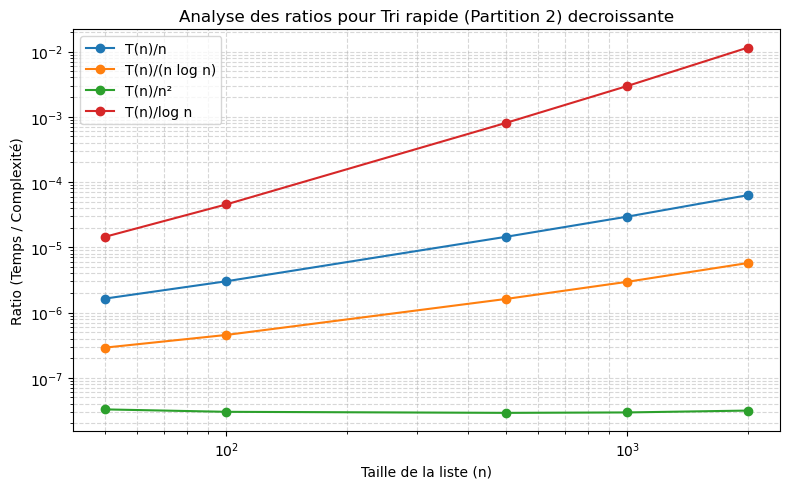

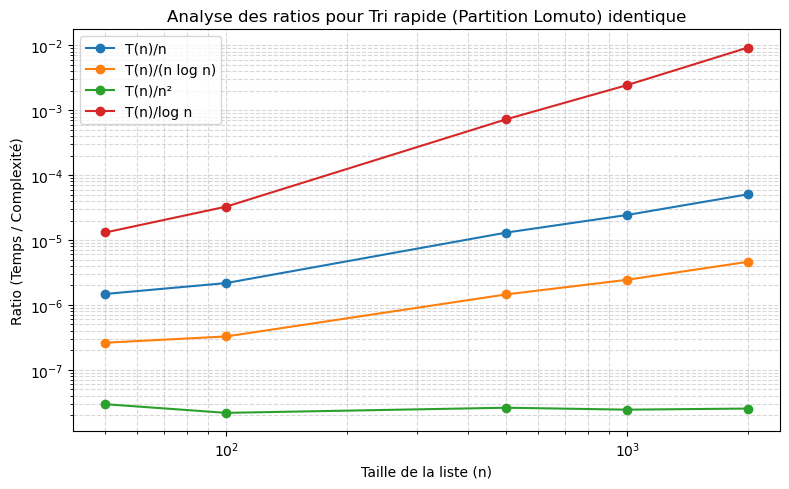

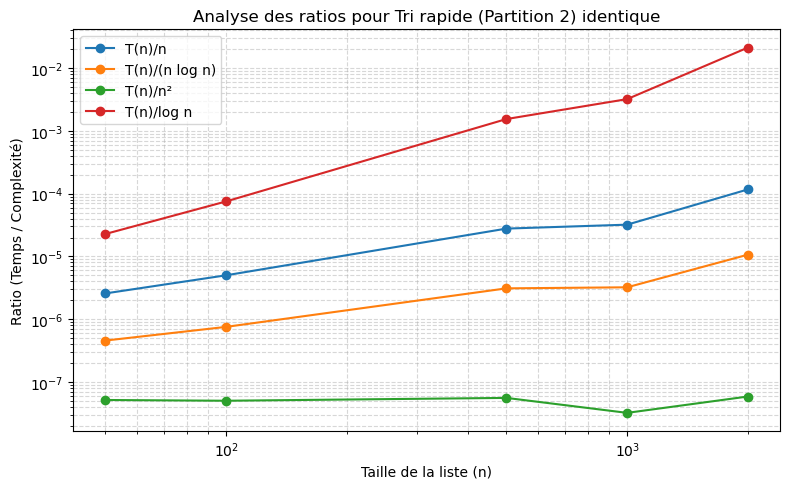

In [14]:
#ce code prends 93 sec pour s'executer

import random
import time
import numpy as np
import matplotlib.pyplot as plt

def partition_lomuto(T, d, f):
    x = T[f]  # pivot
    i = d - 1
    for j in range(d, f):
        if T[j] < x:
            i += 1
            T[i], T[j] = T[j], T[i]
    T[i + 1], T[f] = T[f], T[i + 1]
    return i + 1


def partition_2(T, d, f):
    x = T[f]  # pivot
    indInf = d
    indSup = f - 1
    while indInf <= indSup:
        if T[indInf] < x:
            indInf += 1
        else:
            T[indInf], T[indSup] = T[indSup], T[indInf]
            indSup -= 1
    T[indSup + 1], T[f] = T[f], T[indSup + 1]
    return indSup + 1



def tri_rapide(T, d, f, partition_func):
    if f - d <= 0:
        return
    p = partition_func(T, d, f)
    tri_rapide(T, d, p - 1, partition_func)
    tri_rapide(T, p + 1, f, partition_func)



def temps(partition_func, n, cas="aleatoire"):
    for _ in range(10):
        if cas == "croissant":
            T = list(range(n))
        elif cas == "decroissant":
            T = list(range(n, 0, -1))
        elif cas == "identique":
            T = [5] * n
        else:
            T = [random.randint(1, 1000000) for _ in range(n)]
        t = []
        t1 = time.time()
        tri_rapide(T, 0, len(T) - 1, partition_func)
        t2 = time.time()
        t.append(t2 - t1)
    return sum(t) / len(t)



tmoy_quick_lomuto = {}
tmoy_quick_part2 = {}

tmoy_quick_lomuto_cr = {}
tmoy_quick_part2_cr = {}

tmoy_quick_lomuto_decr = {}
tmoy_quick_part2_decr = {}

tmoy_quick_lomuto_ide = {}
tmoy_quick_part2_ide = {}


t_total1 = time.time()

#aleratoire
print("pour les valleur aleatoire")
for n in [100, 1000, 10000, 100000, 1000000]:
    tmoy_quick_lomuto[f"list_{n}"] = temps(partition_lomuto, n)
    tmoy_quick_part2[f"list_{n}"] = temps(partition_2, n)
    print(f"n={n}: Lomuto={tmoy_quick_lomuto[f'list_{n}']}s | Partition2={tmoy_quick_part2[f'list_{n}']}s")


#croissante
print("pour les valleur croissante")
for n in [50, 100, 500, 1000, 2000]:
    tmoy_quick_lomuto_cr[f"list_{n}"] = temps(partition_lomuto, n, "croissant")
    tmoy_quick_part2_cr[f"list_{n}"] = temps(partition_2, n, "croissant")
    print(f"n={n}: Lomuto={tmoy_quick_lomuto_cr[f'list_{n}']}s | Partition2={tmoy_quick_part2_cr[f'list_{n}']}s")


#decroissant
print("pour les valleur decroissante")
for n in [50, 100, 500, 1000, 2000]:
    tmoy_quick_lomuto_decr[f"list_{n}"] = temps(partition_lomuto, n, "decroissant")
    tmoy_quick_part2_decr[f"list_{n}"] = temps(partition_2, n, "decroissant")
    print(f"n={n}: Lomuto={tmoy_quick_lomuto_decr[f'list_{n}']}s | Partition2={tmoy_quick_part2_decr[f'list_{n}']}s")


#identique
print("pour les valleur identique")
for n in [50, 100, 500, 1000, 2000]:
    tmoy_quick_lomuto_ide[f"list_{n}"] = temps(partition_lomuto, n, "identique")
    tmoy_quick_part2_ide[f"list_{n}"] = temps(partition_2, n, "identique")
    print(f"n={n}: Lomuto={tmoy_quick_lomuto_ide[f'list_{n}']}s | Partition2={tmoy_quick_part2_ide[f'list_{n}']}s")


t_total2 = time.time()
print("temps total :",t_total2 - t_total1)



def plot_graph(algo_name, data_dict, size):
    sizes = np.array(size, dtype=float)
    log_n = np.log2(sizes)
    y = np.array([data_dict[f"list_{int(n)}"] for n in sizes])

    ratios = {
        "T(n)/n": y / sizes,
        "T(n)/(n log n)": y / (sizes * log_n),
        "T(n)/n²": y / (sizes**2),
        "T(n)/log n": y / log_n
    }

    plt.figure(figsize=(8,5))
    for label, ratio in ratios.items():
        plt.plot(sizes, ratio, 'o-', label=label)

    plt.title(f"Analyse des ratios pour {algo_name}")
    plt.xlabel("Taille de la liste (n)")
    plt.ylabel("Ratio (Temps / Complexité)")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Tracer les graphes
plot_graph("Tri rapide (Partition Lomuto) aleatoire", tmoy_quick_lomuto, [100, 1000, 10000, 100000, 1000000])
plot_graph("Tri rapide (Partition 2) aleatoire", tmoy_quick_part2, [100, 1000, 10000, 100000, 1000000])

plot_graph("Tri rapide (Partition Lomuto) croissante", tmoy_quick_lomuto_cr, [50, 100, 500, 1000, 2000])
plot_graph("Tri rapide (Partition 2) croissante", tmoy_quick_part2_cr, [50, 100, 500, 1000, 2000])

plot_graph("Tri rapide (Partition Lomuto) decroissante", tmoy_quick_lomuto_decr, [50, 100, 500, 1000, 2000])
plot_graph("Tri rapide (Partition 2) decroissante", tmoy_quick_part2_decr, [50, 100, 500, 1000, 2000])

plot_graph("Tri rapide (Partition Lomuto) identique", tmoy_quick_lomuto_ide, [50, 100, 500, 1000, 2000])
plot_graph("Tri rapide (Partition 2) identique", tmoy_quick_part2_ide, [50, 100, 500, 1000, 2000])
